# Fusion Results Line Plots

This notebook draws publication-friendly line plots for the provided fusion experiments and adds compact tables plus explanations under each figure.

## Model Order Used on the X-Axis

1. CLIP  
2. CLIP + DINO  
3. CLIP + DINO + MAE  
4. CLIP + DINO + MAE + SigLIP  
5. CLIP + DINO + MAE + SigLIP + ConvNeXt  
6. CLIP + DINO + MAE + SigLIP + ConvNeXt + Data2Vec

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.unicode_minus": False,
})

model_counts = [1, 2, 3, 4, 5, 6]
model_labels = [
    "1\nCLIP",
    "2\n+DINO",
    "3\n+MAE",
    "4\n+SigLIP",
    "5\n+ConvNeXt",
    "6\n+Data2Vec",
]
model_combinations = [
    "CLIP",
    "CLIP + DINO",
    "CLIP + DINO + MAE",
    "CLIP + DINO + MAE + SigLIP",
    "CLIP + DINO + MAE + SigLIP + ConvNeXt",
    "CLIP + DINO + MAE + SigLIP + ConvNeXt + Data2Vec",
]

nan = float("nan")

# --- CIFAR-100: multiple fusion methods (old model order, kept as-is) ---
cifar100_results = {
    "Weighted Sum": [nan, 81.64, 81.92, 82.38, 82.17, 82.05],
    "Gated": [nan, 81.33, 80.39, 82.75, 80.56, 80.18],
    "Difference Concat": [nan, 81.78, 82.01, 82.15, 81.84, 81.37],
    "Hadamard Concat": [nan, 81.87, 81.18, 81.86, 81.86, 81.05],
}
cifar100_baseline = 66.49

# --- All datasets: gated fusion, model count scaling ---
# New results (10-shot few-shot, gated fusion)
new_datasets = {
    "SVHN":    [29.76, 25.68, 26.40, 35.42, 34.05, 32.18],
    "EuroSAT": [83.50, 88.15, 88.11, 86.94, 88.72, 87.65],
    "STL10":   [91.44, 95.34, 95.21, 95.71, 94.74, 94.99],
    "Pets":    [88.99, 94.19, 94.06, 94.71, 95.48, 95.45],
}

# Previous results
other_datasets = {
    "Country211": [29.62, 27.47, 26.92, 27.08, 26.87, 25.92],
    "DTD":        [67.93, 75.85, 75.16, 76.54, 76.70, 76.28],
    "GTSRB":      [67.63, 66.47, 63.30, 75.00, 71.82, 70.75],
}

# Combined: all datasets for the overview plot
all_datasets = {**new_datasets, **other_datasets}

output_dir = Path.cwd()


def display_markdown_table(headers, rows):
    header_line = "| " + " | ".join(headers) + " |"
    separator_line = "| " + " | ".join(["---"] * len(headers)) + " |"
    body_lines = ["| " + " | ".join(row) + " |" for row in rows]
    display(Markdown("\n".join([header_line, separator_line] + body_lines)))

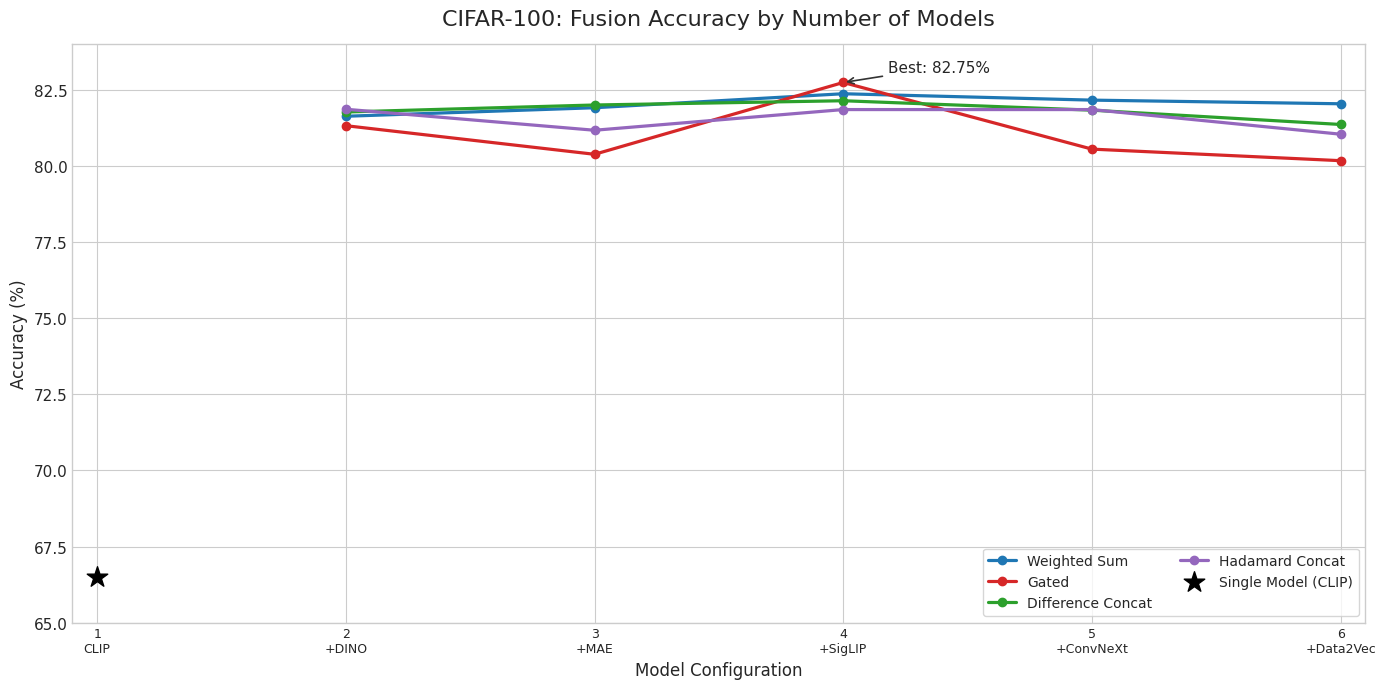

In [2]:
fig, ax = plt.subplots(figsize=(14, 7))

palette = {
    "Weighted Sum": "#1f77b4",
    "Gated": "#d62728",
    "Difference Concat": "#2ca02c",
    "Hadamard Concat": "#9467bd",
}

for name, values in cifar100_results.items():
    ax.plot(
        model_counts,
        values,
        marker="o",
        linewidth=2.3,
        markersize=6,
        label=name,
        color=palette[name],
    )

ax.scatter(
    [1],
    [cifar100_baseline],
    color="black",
    marker="*",
    s=240,
    label="Single Model (CLIP)",
    zorder=6,
)

ax.annotate(
    "Best: 82.75%",
    xy=(4, 82.75),
    xytext=(4.18, 83.1),
    fontsize=11,
    arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#333333"},
)

ax.set_title("CIFAR-100: Fusion Accuracy by Number of Models", fontsize=16, pad=14)
ax.set_xlabel("Model Configuration", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_xticks(model_counts)
ax.set_xticklabels(model_labels)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=11)
ax.set_ylim(65, 84)
ax.legend(ncol=2, frameon=True, fontsize=10)
ax.margins(x=0.02)

plt.tight_layout()
fig.savefig(output_dir / "cifar100_fusion_lineplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
headers = [
    "# Models",
    "Model Combination",
    "Weighted Sum",
    "Gated",
    "Difference Concat",
    "Hadamard Concat",
]

rows = []
for idx, count in enumerate(model_counts):
    weighted = "-" if idx == 0 else f"{cifar100_results['Weighted Sum'][idx]:.2f}%"
    gated = "-" if idx == 0 else f"{cifar100_results['Gated'][idx]:.2f}%"
    diff = "-" if idx == 0 else f"{cifar100_results['Difference Concat'][idx]:.2f}%"
    hadamard = "-" if idx == 0 else f"{cifar100_results['Hadamard Concat'][idx]:.2f}%"
    rows.append([
        str(count),
        model_combinations[idx],
        weighted,
        gated,
        diff,
        hadamard,
    ])

display(Markdown("### CIFAR-100 Table"))
display_markdown_table(headers, rows)


### CIFAR-100 Table

| # Models | Model Combination | Weighted Sum | Gated | Difference Concat | Hadamard Concat |
| --- | --- | --- | --- | --- | --- |
| 1 | CLIP | - | - | - | - |
| 2 | CLIP + DINO | 81.64% | 81.33% | 81.78% | 81.87% |
| 3 | CLIP + DINO + MAE | 81.92% | 80.39% | 82.01% | 81.18% |
| 4 | CLIP + DINO + MAE + SigLIP | 82.38% | 82.75% | 82.15% | 81.86% |
| 5 | CLIP + DINO + MAE + SigLIP + ConvNeXt | 82.17% | 80.56% | 81.84% | 81.86% |
| 6 | CLIP + DINO + MAE + SigLIP + ConvNeXt + Data2Vec | 82.05% | 80.18% | 81.37% | 81.05% |

### Explanation

- The single-model CLIP baseline starts at **66.49%**, while all 2-model fusion variants jump above **81%**, showing a clear gain from fusion.
- The best result is **Gated fusion with 4 models** (`MAE + CLIP + DINO + SigLIP`), reaching **82.75%**.
- Performance improves from 2 models to 4 models, but adding more models does not continue to help. This suggests that extra models can introduce redundancy or representation mismatch.
- Overall, **4 models** is the most effective scale for CIFAR-100 in this experiment.

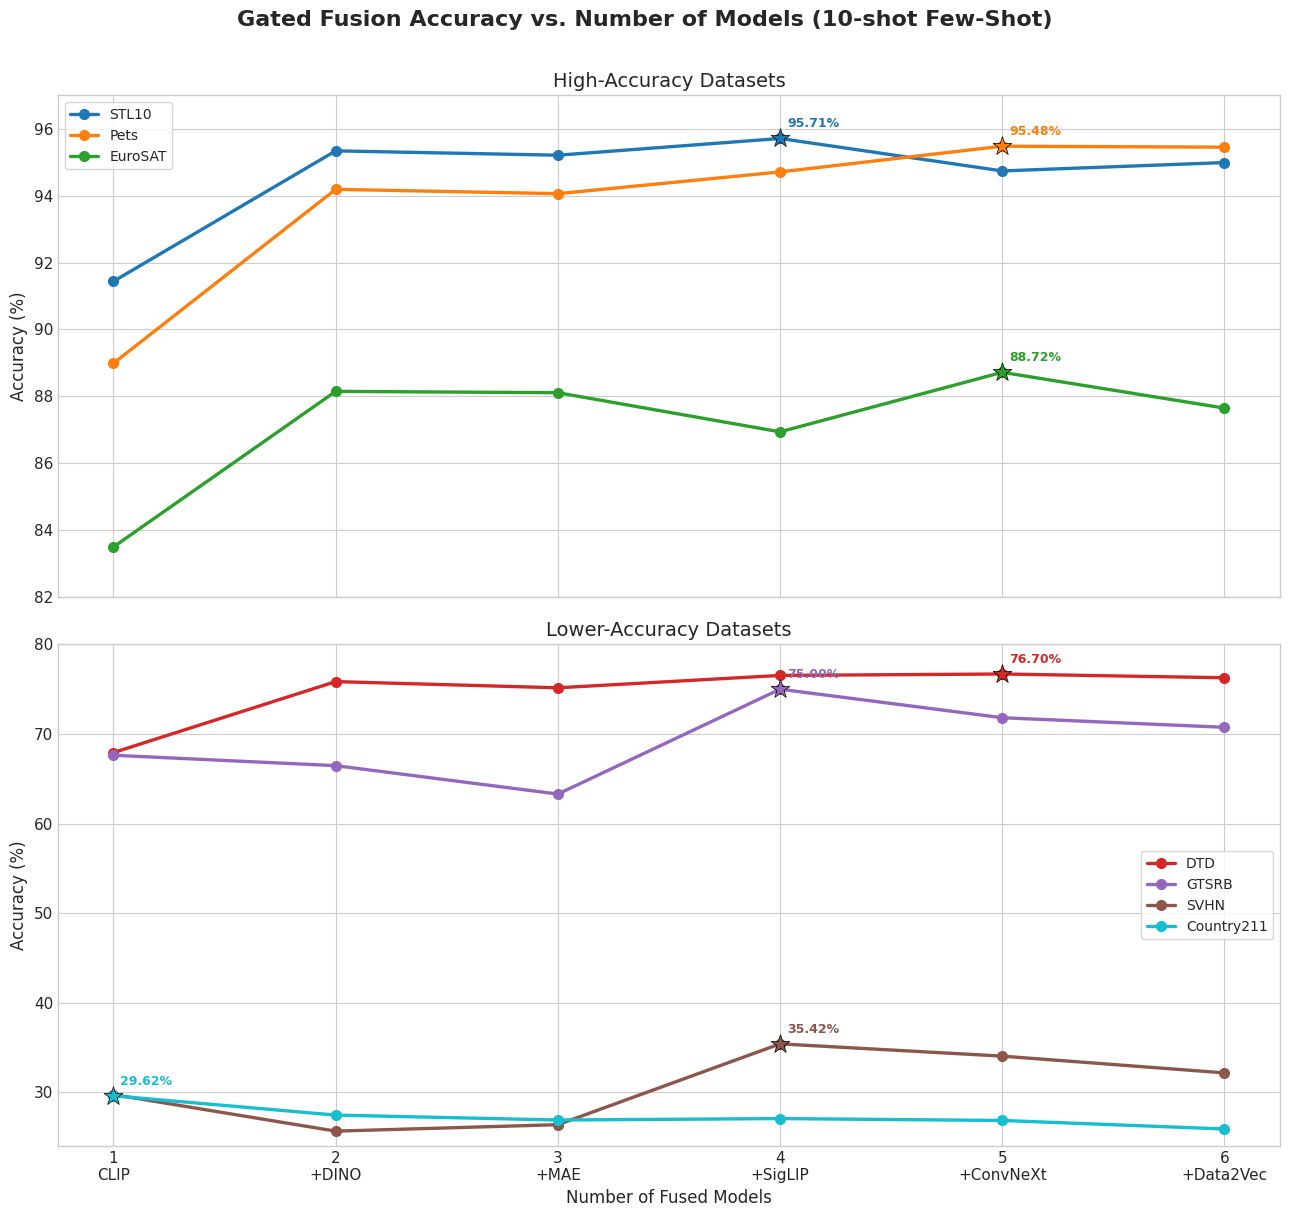

In [4]:
# ── All Datasets: accuracy vs number of models (gated fusion, 10-shot) ──
fig, axes = plt.subplots(2, 1, figsize=(13, 12), sharex=True)

palette = {
    "STL10":      "#1f77b4",
    "Pets":       "#ff7f0e",
    "EuroSAT":    "#2ca02c",
    "DTD":        "#d62728",
    "GTSRB":      "#9467bd",
    "SVHN":       "#8c564b",
    "Country211": "#17becf",
}

# Group 1: high-accuracy datasets (top subplot)
high_acc = {"STL10": all_datasets["STL10"], "Pets": all_datasets["Pets"], "EuroSAT": all_datasets["EuroSAT"]}
# Group 2: lower-accuracy datasets (bottom subplot)
low_acc = {"DTD": all_datasets["DTD"], "GTSRB": all_datasets["GTSRB"], "SVHN": all_datasets["SVHN"], "Country211": all_datasets["Country211"]}

for ax, group, title, ylim in [
    (axes[0], high_acc, "High-Accuracy Datasets", (82, 97)),
    (axes[1], low_acc, "Lower-Accuracy Datasets", (24, 80)),
]:
    for name, values in group.items():
        ax.plot(
            model_counts, values,
            marker="o", linewidth=2.4, markersize=7,
            label=name, color=palette[name],
        )
        # Mark the best point with a star
        best_idx = max(range(len(values)), key=lambda i: values[i])
        ax.scatter(
            model_counts[best_idx], values[best_idx],
            marker="*", s=200, color=palette[name], zorder=6,
            edgecolors="black", linewidths=0.5,
        )
        ax.annotate(
            f"{values[best_idx]:.2f}%",
            xy=(model_counts[best_idx], values[best_idx]),
            xytext=(5, 8), textcoords="offset points",
            fontsize=9, fontweight="bold", color=palette[name],
        )

    ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_ylim(*ylim)
    ax.legend(frameon=True, fontsize=10, loc="best")
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis="both", labelsize=11)

axes[1].set_xlabel("Number of Fused Models", fontsize=12)
axes[1].set_xticks(model_counts)
axes[1].set_xticklabels(model_labels)

fig.suptitle(
    "Gated Fusion Accuracy vs. Number of Models (10-shot Few-Shot)",
    fontsize=16, fontweight="bold", y=1.01,
)

plt.tight_layout()
fig.savefig(output_dir / "all_datasets_lineplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# ── Summary table: all datasets ──
dataset_names = list(all_datasets.keys())
headers = ["# Models", "Model Combination"] + dataset_names
rows = []

for idx, count in enumerate(model_counts):
    row = [str(count), model_combinations[idx]]
    for ds in dataset_names:
        val = all_datasets[ds][idx]
        best_val = max(all_datasets[ds])
        cell = f"**{val:.2f}%**" if val == best_val else f"{val:.2f}%"
        row.append(cell)
    rows.append(row)

display(Markdown("### All Datasets: Gated Fusion (10-shot)"))
display_markdown_table(headers, rows)

# Best model count per dataset
display(Markdown("\n### Optimal Model Count per Dataset\n"))
opt_headers = ["Dataset", "Best Accuracy", "Optimal # Models"]
opt_rows = []
for ds in dataset_names:
    vals = all_datasets[ds]
    best_idx = max(range(len(vals)), key=lambda i: vals[i])
    opt_rows.append([ds, f"{vals[best_idx]:.2f}%", str(model_counts[best_idx])])
display_markdown_table(opt_headers, opt_rows)

### All Datasets: Gated Fusion (10-shot)

| # Models | Model Combination | SVHN | EuroSAT | STL10 | Pets | Country211 | DTD | GTSRB |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | CLIP | 29.76% | 83.50% | 91.44% | 88.99% | **29.62%** | 67.93% | 67.63% |
| 2 | CLIP + DINO | 25.68% | 88.15% | 95.34% | 94.19% | 27.47% | 75.85% | 66.47% |
| 3 | CLIP + DINO + MAE | 26.40% | 88.11% | 95.21% | 94.06% | 26.92% | 75.16% | 63.30% |
| 4 | CLIP + DINO + MAE + SigLIP | **35.42%** | 86.94% | **95.71%** | 94.71% | 27.08% | 76.54% | **75.00%** |
| 5 | CLIP + DINO + MAE + SigLIP + ConvNeXt | 34.05% | **88.72%** | 94.74% | **95.48%** | 26.87% | **76.70%** | 71.82% |
| 6 | CLIP + DINO + MAE + SigLIP + ConvNeXt + Data2Vec | 32.18% | 87.65% | 94.99% | 95.45% | 25.92% | 76.28% | 70.75% |


### Optimal Model Count per Dataset


| Dataset | Best Accuracy | Optimal # Models |
| --- | --- | --- |
| SVHN | 35.42% | 4 |
| EuroSAT | 88.72% | 5 |
| STL10 | 95.71% | 4 |
| Pets | 95.48% | 5 |
| Country211 | 29.62% | 1 |
| DTD | 76.70% | 5 |
| GTSRB | 75.00% | 4 |

### Key Findings

**High-accuracy group (STL10, Pets, EuroSAT):**
- All three datasets show a clear jump from 1 model to 2 models (CLIP → CLIP + DINO), gaining **3-5%** accuracy.
- After the initial jump, further models bring diminishing or fluctuating returns.
- **STL10** peaks at 4 models (**95.71%**), **Pets** at 5 models (**95.48%**), **EuroSAT** at 5 models (**88.72%**).
- Adding the 6th model (Data2Vec) slightly degrades all three, suggesting Data2Vec is somewhat redundant in these domains.

**Lower-accuracy group (DTD, GTSRB, SVHN, Country211):**
- **SVHN** has an unusual pattern: fusion initially *hurts* (drops from 29.76% to 25.68%), but then spikes at 4 models (**35.42%**). This suggests SigLIP provides complementary signal for digit recognition.
- **DTD** and **GTSRB** both peak at 4-5 models, consistent with the trend above.
- **Country211** never benefits from fusion — single-model CLIP remains the best (**29.62%**).

**Cross-dataset pattern:**
- The optimal model count is **dataset-dependent** (4 or 5 models for most, 1 for Country211).
- More models $\neq$ better performance; there is a sweet spot beyond which redundancy or interference hurts.
- This motivates **dynamic routing methods** (topk_router, moe_router, attention_router) that can automatically learn the optimal model subset per sample.

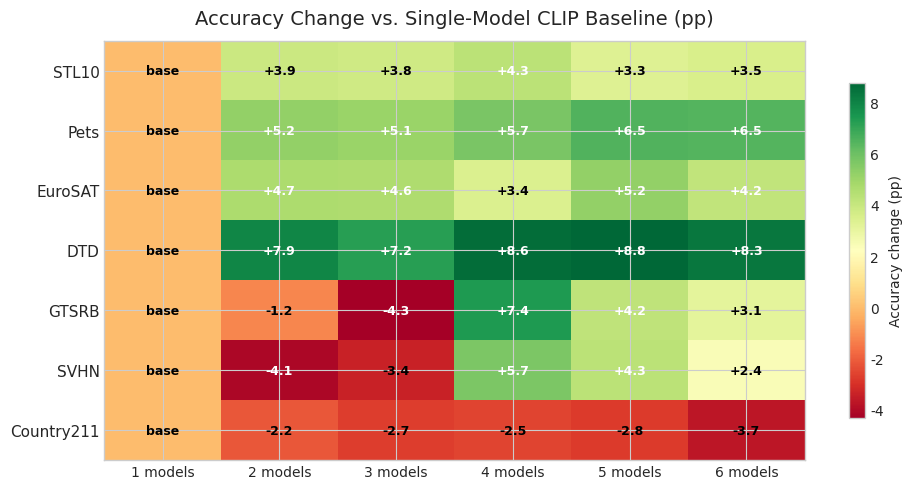

In [6]:
# ── Heatmap: relative accuracy change vs single model baseline ──
fig, ax = plt.subplots(figsize=(10, 5))

dataset_names_sorted = ["STL10", "Pets", "EuroSAT", "DTD", "GTSRB", "SVHN", "Country211"]
data_matrix = []
for ds in dataset_names_sorted:
    baseline_val = all_datasets[ds][0]
    row = [(v - baseline_val) for v in all_datasets[ds]]
    data_matrix.append(row)

data_matrix = np.array(data_matrix)

im = ax.imshow(data_matrix, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(6))
ax.set_xticklabels([f"{c} models" for c in model_counts], fontsize=10)
ax.set_yticks(range(len(dataset_names_sorted)))
ax.set_yticklabels(dataset_names_sorted, fontsize=11)

# Annotate cells
for i in range(len(dataset_names_sorted)):
    for j in range(6):
        val = data_matrix[i, j]
        text = f"{val:+.1f}" if j > 0 else "base"
        color = "white" if abs(val) > 4 else "black"
        ax.text(j, i, text, ha="center", va="center", fontsize=9, fontweight="bold", color=color)

ax.set_title("Accuracy Change vs. Single-Model CLIP Baseline (pp)", fontsize=14, pad=12)
fig.colorbar(im, ax=ax, label="Accuracy change (pp)", shrink=0.8)

plt.tight_layout()
fig.savefig(output_dir / "fusion_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Round 1: Dynamic Routing Methods Comparison

**实验配置**: 6 模型 (CLIP+DINO+MAE+SigLIP+ConvNeXt+Data2Vec), 10-shot few-shot, 10 epochs, router_k=2

> **注意**: 本轮实验与上方"模型数量递增"实验的训练配置不同（epoch 数、数据量等），数值不可直接对比。本轮重点是**同一配置下不同路由方法之间的横向比较**。

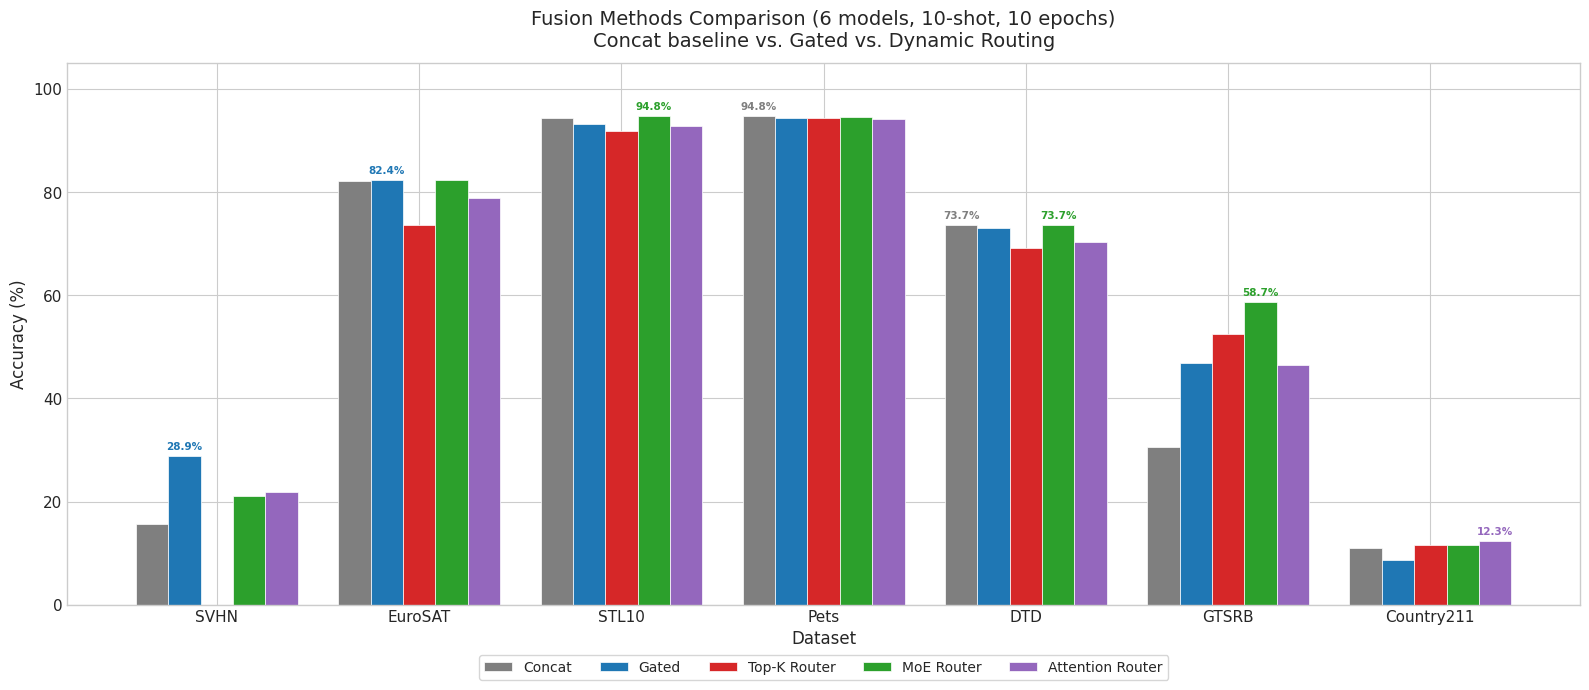

In [7]:
# ── Round 1: Dynamic Routing Results (with Concat baseline) ──
routing_datasets = ["SVHN", "EuroSAT", "STL10", "Pets", "DTD", "GTSRB", "Country211"]
routing_methods = ["Concat", "Gated", "Top-K Router", "MoE Router", "Attention Router"]
routing_results = {
    #                   concat  gated   topk    moe     attn
    "SVHN":       [15.63, 28.93, nan,   21.17, 21.91],
    "EuroSAT":    [82.13, 82.44, 73.61, 82.35, 78.85],
    "STL10":      [94.41, 93.17, 91.91, 94.75, 92.85],
    "Pets":       [94.79, 94.47, 94.47, 94.63, 94.19],
    "DTD":        [73.67, 73.09, 69.15, 73.67, 70.43],
    "GTSRB":      [30.55, 46.93, 52.49, 58.72, 46.49],
    "Country211": [11.07,  8.72, 11.63, 11.52, 12.34],
}

routing_palette = {
    "Concat":           "#7f7f7f",
    "Gated":            "#1f77b4",
    "Top-K Router":     "#d62728",
    "MoE Router":       "#2ca02c",
    "Attention Router": "#9467bd",
}

# ── Bar chart ──
fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(routing_datasets))
width = 0.16
offsets = [-2, -1, 0, 1, 2]

for i, method in enumerate(routing_methods):
    vals = [routing_results[ds][i] for ds in routing_datasets]
    ax.bar(
        x + offsets[i] * width, vals, width,
        label=method, color=routing_palette[method],
        edgecolor="white", linewidth=0.5,
    )
    # Label the best per dataset
    for j, ds in enumerate(routing_datasets):
        all_vals = routing_results[ds]
        valid_vals = [v for v in all_vals if not np.isnan(v)]
        if not np.isnan(vals[j]) and vals[j] == max(valid_vals):
            ax.text(
                x[j] + offsets[i] * width, vals[j] + 0.8,
                f"{vals[j]:.1f}%", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color=routing_palette[method],
            )

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Fusion Methods Comparison (6 models, 10-shot, 10 epochs)\nConcat baseline vs. Gated vs. Dynamic Routing", fontsize=14, pad=12)
ax.set_xticks(x)
ax.set_xticklabels(routing_datasets, fontsize=11)
ax.legend(fontsize=10, frameon=True, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.08))
ax.tick_params(axis="y", labelsize=11)
ax.set_ylim(0, 105)

plt.tight_layout()
fig.savefig(output_dir / "routing_round1_bar.png", dpi=300, bbox_inches="tight")
plt.show()

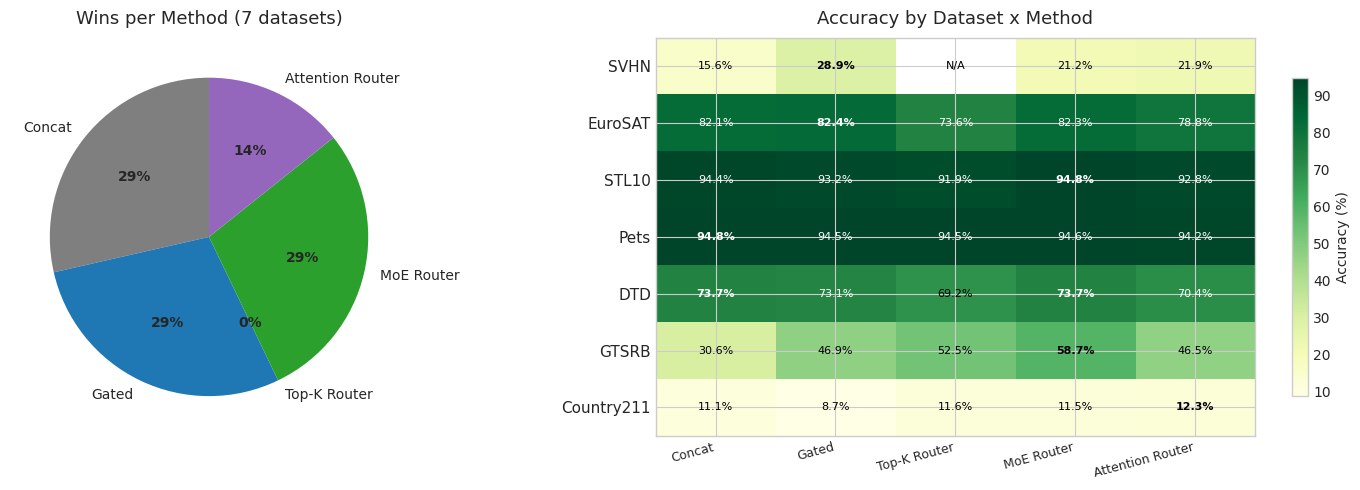

In [8]:
# ── Round 1: Win-count pie + relative improvement heatmap ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Pie chart: wins per method ---
wins = {m: 0 for m in routing_methods}
for ds in routing_datasets:
    vals = routing_results[ds]
    valid = [(v, i) for i, v in enumerate(vals) if not np.isnan(v)]
    best_i = max(valid, key=lambda t: t[0])[1]
    wins[routing_methods[best_i]] += 1

colors = [routing_palette[m] for m in wins.keys()]
wedges, texts, autotexts = ax1.pie(
    wins.values(), labels=wins.keys(), autopct="%1.0f%%",
    colors=colors, startangle=90, textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
ax1.set_title("Wins per Method (7 datasets)", fontsize=13, pad=10)

# --- Heatmap: accuracy by dataset × method ---
matrix = []
for ds in routing_datasets:
    matrix.append(routing_results[ds])
matrix = np.array(matrix)

n_methods = len(routing_methods)
im = ax2.imshow(matrix, cmap="YlGn", aspect="auto")
ax2.set_xticks(range(n_methods))
ax2.set_xticklabels(routing_methods, fontsize=9, rotation=15, ha="right")
ax2.set_yticks(range(len(routing_datasets)))
ax2.set_yticklabels(routing_datasets, fontsize=11)

for i in range(len(routing_datasets)):
    valid_vals = [v for v in matrix[i] if not np.isnan(v)]
    best_val = max(valid_vals) if valid_vals else -1
    for j in range(n_methods):
        val = matrix[i, j]
        if np.isnan(val):
            text = "N/A"
        else:
            text = f"{val:.1f}%"
        weight = "bold" if (not np.isnan(val) and val == best_val) else "normal"
        color = "white" if (not np.isnan(val) and val > 70) else "black"
        ax2.text(j, i, text, ha="center", va="center", fontsize=8, fontweight=weight, color=color)

ax2.set_title("Accuracy by Dataset x Method", fontsize=13, pad=10)
fig.colorbar(im, ax=ax2, label="Accuracy (%)", shrink=0.8)

plt.tight_layout()
fig.savefig(output_dir / "routing_round1_summary.png", dpi=300, bbox_inches="tight")
plt.show()

### Round 1 Key Findings

1. **Concat baseline 意外表现不错**：在 STL10 (94.41%) 和 Pets (94.79%) 上，简单拼接甚至优于所有动态路由方法。说明这些高准确率数据集上，模型特征天然互补，复杂路由反而增加训练难度。
2. **MoE Router 在中等难度任务上稳定领先**：GTSRB (58.72%) 大幅超越 Concat (30.55%) +28.17pp，DTD 上与 Concat 持平 (73.67%)。soft routing + load-balancing 对交通标志等需要自适应选择模型的任务帮助最大。
3. **Gated 在 SVHN 上大幅超越 Concat**：28.93% vs 15.63%，+13.30pp。SVHN 的 digit 识别需要自适应权重来抑制不相关模型的噪声。
4. **Attention Router 在 Country211 上最佳** (12.34%)：高类别数 (211类) 任务从模型间交互建模获益，但整体提升有限。
5. **动态路由 vs Concat 的选择取决于数据集特性**：简单数据集用 Concat 即可，复杂/不平衡数据集（如 GTSRB）则需要 MoE/Gated 路由。

---

## Round 2: Top-K Router k-Value Ablation

**实验配置**: 6 模型, 10-shot few-shot, 10 epochs, k = 1, 2, 3, 4, 5

> 验证 Top-K Router 的 k 值对性能的影响。Round 1 中 k=2 表现最差，本轮探索更大 k 值能否改善。

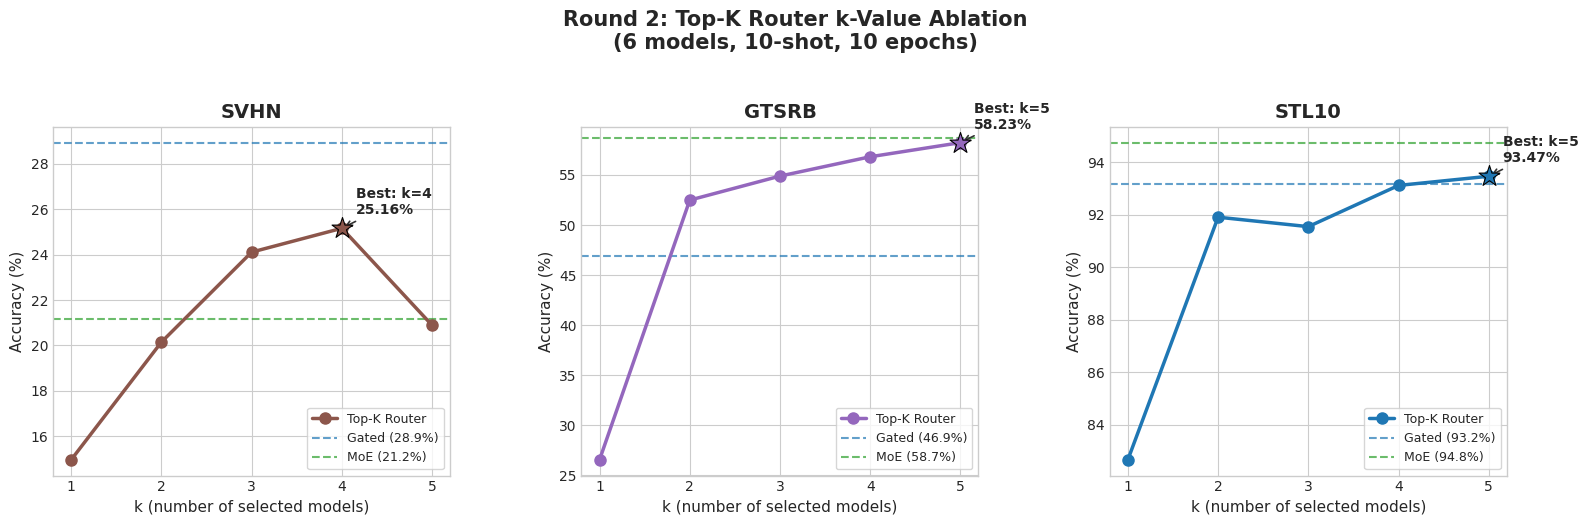

In [9]:
# ── Round 2: Top-K Router k-value ablation ──
k_values = [1, 2, 3, 4, 5]
topk_ablation = {
    "SVHN":  [14.97, 20.15, 24.11, 25.16, 20.89],
    "GTSRB": [26.56, 52.49, 54.89, 56.82, 58.23],
    "STL10": [82.67, 91.91, 91.55, 93.12, 93.47],
}

# Also store Round 1 best non-topk results for reference lines
round1_best = {
    "SVHN":  {"Gated": 28.93, "MoE": 21.17},
    "GTSRB": {"Gated": 46.93, "MoE": 58.72},
    "STL10": {"Gated": 93.17, "MoE": 94.75},
}

topk_palette = {"SVHN": "#8c564b", "GTSRB": "#9467bd", "STL10": "#1f77b4"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, ds in zip(axes, ["SVHN", "GTSRB", "STL10"]):
    vals = topk_ablation[ds]
    ax.plot(k_values, vals, marker="o", linewidth=2.5, markersize=8,
            color=topk_palette[ds], label="Top-K Router", zorder=5)

    # Mark best k
    best_idx = max(range(len(vals)), key=lambda i: vals[i])
    ax.scatter(k_values[best_idx], vals[best_idx], marker="*", s=250,
               color=topk_palette[ds], edgecolors="black", linewidths=0.8, zorder=6)
    ax.annotate(f"Best: k={k_values[best_idx]}\n{vals[best_idx]:.2f}%",
                xy=(k_values[best_idx], vals[best_idx]),
                xytext=(10, 10), textcoords="offset points",
                fontsize=10, fontweight="bold",
                arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#333"})

    # Reference lines from Round 1
    gated_val = round1_best[ds]["Gated"]
    moe_val = round1_best[ds]["MoE"]
    ax.axhline(gated_val, color="#1f77b4", linestyle="--", linewidth=1.5, alpha=0.7, label=f"Gated ({gated_val:.1f}%)")
    ax.axhline(moe_val, color="#2ca02c", linestyle="--", linewidth=1.5, alpha=0.7, label=f"MoE ({moe_val:.1f}%)")

    ax.set_title(ds, fontsize=14, fontweight="bold")
    ax.set_xlabel("k (number of selected models)", fontsize=11)
    ax.set_ylabel("Accuracy (%)", fontsize=11)
    ax.set_xticks(k_values)
    ax.legend(fontsize=9, frameon=True, loc="lower right")
    ax.tick_params(labelsize=10)

fig.suptitle("Round 2: Top-K Router k-Value Ablation\n(6 models, 10-shot, 10 epochs)",
             fontsize=15, fontweight="bold", y=1.04)

plt.tight_layout()
fig.savefig(output_dir / "routing_round2_topk_ablation.png", dpi=300, bbox_inches="tight")
plt.show()

### Round 2 分析

**核心发现：Top-K Router 的硬选择本质上劣于 soft routing**

1. **k=1 灾难性差**：SVHN 14.97%、GTSRB 26.56%、STL10 82.67%。强制只选 1 个模型时，straight-through estimator 的梯度过于稀疏，路由器根本学不好。

2. **GTSRB 和 STL10 单调递增（k↑ → acc↑）**：这两个数据集从 k=1 到 k=5 准确率持续上升，说明它们更需要多模型协同，而非模型筛选。k=5（选 5/6 个模型）本质上已接近 soft routing。

3. **SVHN 是唯一出现"甜点"的数据集**：k=4 (25.16%) > k=5 (20.89%)，说明 SVHN 确实存在需要排除的模型——路由器学会了丢弃 2 个最无用的模型。但即使是最优 k=4，仍然低于 Gated (28.93%)。

4. **即使 k 值最优，Top-K 仍难以匹敌 soft 方法**：
   - SVHN: Top-K best (25.16%) < Gated (28.93%)，差 3.77pp
   - GTSRB: Top-K best (58.23%) ≈ MoE (58.72%)，仅差 0.49pp，几乎追平
   - STL10: Top-K best (93.47%) < MoE (94.75%)，差 1.28pp

5. **结论：Top-K Router 的价值在于可解释性而非性能**。它能明确告诉你每个样本选了哪些模型，但硬选择引入的梯度噪声使其性能天花板低于 MoE 的 soft routing。如果目标是最高准确率，用 MoE Router；如果目标是分析模型贡献度，用 Top-K Router。